In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Embedding,Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')
print(f'Tensorflow version:{tf.__version__}')
print('All libraries imported!')

C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ishas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tensorflow version:2.21.0
All libraries imported!


In [3]:
#load clean transaction data
df=pd.read_csv('cognicart/data/cleaned/supermarket_clean.csv')
#sort by Customerid and date
df=df.sort_values(['Customer_ID','Date'])
print('Data loaded!')
print(f'Shape:{df.shape}')
print(f'Unique customers:{df['Customer_ID'].nunique()}')
print(f'Unique products:{df['Product'].nunique()}')
print()
print('Sample Data:')
print(df[['Customer_ID','Date','Product']].head(10))



Data loaded!
Shape:(27596, 13)
Unique customers:500
Unique products:43

Sample Data:
     Customer_ID        Date      Product
9815       C0001  2024-01-08        Chips
9816       C0001  2024-01-08        Bread
9817       C0001  2024-01-08      Shampoo
9818       C0001  2024-01-08  Wheat Flour
8327       C0001  2024-05-30  Tomatosauce
8328       C0001  2024-05-30       Coffee
8329       C0001  2024-05-30        Chips
8330       C0001  2024-05-30  Waterbottle
8331       C0001  2024-05-30        Bread
8332       C0001  2024-05-30          Tea


In [4]:
#create label encoder for products
le=LabelEncoder()
#fit encoder on all products
df['ProductCode']=le.fit_transform(df['Product'])
#save mapping for later use
product_to_code=dict(zip(le.classes_,le.transform(le.classes_)))
code_to_product=dict(zip(le.transform(le.classes_),le.classes_))
NUM_PRODUCTS=len(le.classes_)
print(f'Total unique products:{NUM_PRODUCTS}')
print()
print('Product encoding examples:')
for product,code in list(product_to_code.items())[:8]:
    print(f'{product}-->{code}')

Total unique products:43

Product encoding examples:
Apple-->0
Banana-->1
Biscuit-->2
Biscuits-->3
Bread-->4
Brown Bread-->5
Butter-->6
Carrot-->7


In [5]:
#create purchase sequence
SEQUENCE_LENGTH=5#use last 5 purchase to predict next
x=[]#input sequences
y=[]#target next product
#group product by customer in order
customer_sequences=df.groupby('Customer_ID')['ProductCode'].apply(list)
for customer_id,products in customer_sequences.items():
    #need at least SEQUENCE_LENGTH+1 purchases
    if len(products)<SEQUENCE_LENGTH+1:
        continue
    #create sliding window sequences
    for i in range(len(products)-SEQUENCE_LENGTH):
        sequence=products[i:i+SEQUENCE_LENGTH]
        next_item=products[i+SEQUENCE_LENGTH]
        x.append(sequence)
        y.append(next_item)
x=np.array(x)
y=np.array(y)
print(f'Total training sequences:{len(x)}')
print(f'Sequence Shape:{x.shape}')
print()
print('Example sequence:')
print(f'input:{x[0]}={[code_to_product[c] for c in x[0]]}')
print(f'Target:{y[0]}={code_to_product[y[0]]}')

Total training sequences:25096
Sequence Shape:(25096, 5)

Example sequence:
input:[ 9  4 33 42 39]=['Chips', 'Bread', 'Shampoo', 'Wheat Flour', 'Tomatosauce']
Target:11=Coffee


In [6]:
#convert target into onehotencoder
from sklearn.model_selection import train_test_split
y_encoded=to_categorical(y,num_classes=NUM_PRODUCTS)
x_train,x_test,y_train,y_test=train_test_split(
    x,y_encoded,
    test_size=0.2,
    random_state=42
)
print(f'training sample:{len(x_train)}')
print(f'testing sample:{len(x_test)}')
print(f'input sahpe:{x_train.shape}')
print(f'output shape:{y_train.shape}')


training sample:20076
testing sample:5020
input sahpe:(20076, 5)
output shape:(20076, 43)


In [7]:
#building LSTM model
model=Sequential([
    Embedding(
        input_dim=NUM_PRODUCTS,
        output_dim=64,
        input_length=SEQUENCE_LENGTH
    ),
    LSTM(
        units=128,
        return_sequences=True
    ),
    Dropout(0.3),
    LSTM(
        units=64,
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(128,activation='relu'),
    Dense(NUM_PRODUCTS,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
#compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.build(input_shape=(None, SEQUENCE_LENGTH))
print('Model compiled')
print(f'Total parameters:{model.count_params():,}')

Model compiled
Total parameters:164,843


In [9]:
#train model
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint=ModelCheckpoint(
    'cognicart/models/lstm_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
history=model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop,checkpoint],
    verbose=1
)
print('Training complete')

Epoch 1/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0908 - loss: 3.5232
Epoch 1: val_accuracy improved from None to 0.22311, saving model to cognicart/models/lstm_best.h5



Epoch 1: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.1234 - loss: 3.3551 - val_accuracy: 0.2231 - val_loss: 2.9759
Epoch 2/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2264 - loss: 2.9731
Epoch 2: val_accuracy improved from 0.22311 to 0.29482, saving model to cognicart/models/lstm_best.h5



Epoch 2: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2361 - loss: 2.9217 - val_accuracy: 0.2948 - val_loss: 2.7418
Epoch 3/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2759 - loss: 2.7811
Epoch 3: val_accuracy improved from 0.29482 to 0.31873, saving model to cognicart/models/lstm_best.h5



Epoch 3: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2829 - loss: 2.7676 - val_accuracy: 0.3187 - val_loss: 2.6552
Epoch 4/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3034 - loss: 2.6824
Epoch 4: val_accuracy improved from 0.31873 to 0.33516, saving model to cognicart/models/lstm_best.h5



Epoch 4: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3045 - loss: 2.6903 - val_accuracy: 0.3352 - val_loss: 2.5956
Epoch 5/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3229 - loss: 2.6160
Epoch 5: val_accuracy improved from 0.33516 to 0.33865, saving model to cognicart/models/lstm_best.h5


...


Epoch 9: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3517 - loss: 2.4719 - val_accuracy: 0.3755 - val_loss: 2.4672
Epoch 10/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3567 - loss: 2.4163
Epoch 10: val_accuracy improved from 0.37550 to 0.38048, saving model to cognicart/models/lstm_best.h5



Epoch 10: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3546 - loss: 2.4344 - val_accuracy: 0.3805 - val_loss: 2.4501
Epoch 11/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3674 - loss: 2.4000
Epoch 11: val_accuracy did not improve from 0.38048
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3640 - loss: 2.4132 - val_accuracy: 0.3795 - val_loss: 2.4486
Epoch 12/30
560/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3726 - loss: 2.3794
Epoch 12: val_accuracy did not improve from 0.38048
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3677 - loss: 2.3896 - val_accuracy: 0.3765 - val_loss: 2.4450
Epoch 13/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3761 - loss: 2.3368
Epoch 13: val_accuracy improved from 0.38048 to 0.38197, saving model to cognicart/models/lstm_best.h5



Epoch 13: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3757 - loss: 2.3571 - val_accuracy: 0.3820 - val_loss: 2.4302
Epoch 14/30
562/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3737 - loss: 2.3456
Epoch 14: val_accuracy improved from 0.38197 to 0.38645, saving model to cognicart/models/lstm_best.h5



Epoch 14: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3775 - loss: 2.3442 - val_accuracy: 0.3865 - val_loss: 2.4483
Epoch 15/30
564/565 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3849 - loss: 2.2951
Epoch 15: val_accuracy did not improve from 0.38645
565/565 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3802 - loss: 2.3126 - val_accuracy: 0.3820 - val_loss: 2.4557
Epoch 16/30
563/565 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3829 - loss: 2.2801
Epoch 16: val_accuracy did not improve from 0.38645
565/565 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3828 - loss: 2.2908 - val_accuracy: 0.3800 - val_loss: 2.4510
Epoch 17/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3951 - loss: 2.2473
Epoch 17: val_accuracy did not improve from 0.38645
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3868 - loss: 2.2693 - val_accuracy: 0.3775 - val_loss: 2.4528
Epoch 18/30
565/565 ━━━━━━━━━━━━━━━━━━━


Epoch 18: finished saving model to cognicart/models/lstm_best.h5
565/565 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3916 - loss: 2.2479 - val_accuracy: 0.3889 - val_loss: 2.4508
Training complete


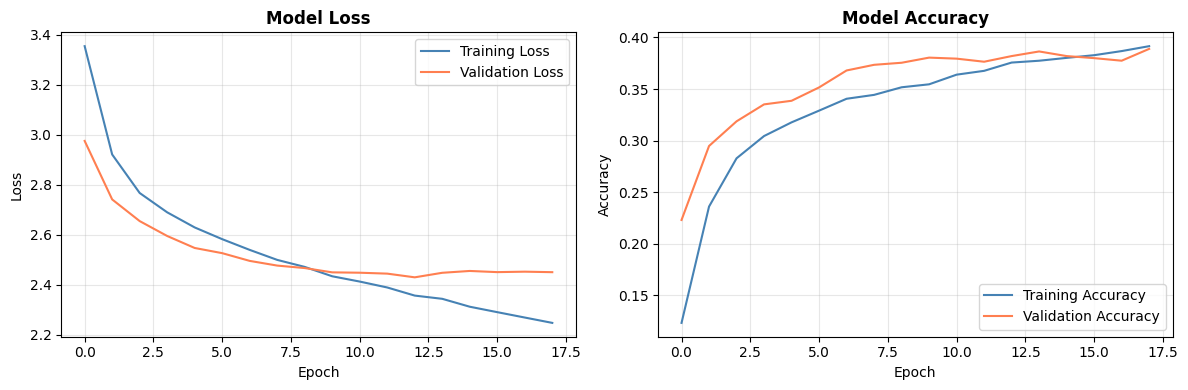

Training charts saved!


In [10]:
 fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],
             label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='coral')
axes[0].set_title('Model Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'],
             label='Training Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'],
             label='Validation Accuracy', color='coral')
axes[1].set_title('Model Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cognicart/outputs/week5_training.png', dpi=150)
plt.show()
print('Training charts saved!')


In [11]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')
print()

# Top-3 accuracy (predict in top 3 = correct)
predictions = model.predict(x_test)

top3_correct = 0
for i in range(len(predictions)):
    top3_preds = np.argsort(predictions[i])[-3:]
    true_label = np.argmax(y_test[i])
    if true_label in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(predictions)
print(f'Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.1f}%)')


Test Loss:     2.4859
Test Accuracy: 0.3602 (36.0%)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Top-3 Accuracy: 0.5456 (54.6%)


In [12]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')
print()

# Top-3 accuracy (predict in top 3 = correct)
predictions = model.predict(x_test)

top3_correct = 0
for i in range(len(predictions)):
    top3_preds = np.argsort(predictions[i])[-3:]
    true_label = np.argmax(y_test[i])
    if true_label in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(predictions)
print(f'Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.1f}%)')


Test Loss:     2.4859
Test Accuracy: 0.3602 (36.0%)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Top-3 Accuracy: 0.5456 (54.6%)


In [13]:
import pickle
import os

# Save final model
model.save('cognicart/models/lstm_final.h5')
print('LSTM model saved!')

# Save label encoder
with open('cognicart/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Label encoder saved!')

# Save product mappings
mappings = {
'product_to_code': product_to_code,
'code_to_product': code_to_product,
'num_products': NUM_PRODUCTS,
'sequence_length': SEQUENCE_LENGTH
}
with open('cognicart/models/product_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)
print('Product mappings saved!')
print()
print('All model files saved to cognicart/models/')


LSTM model saved!
Label encoder saved!
Product mappings saved!

All model files saved to cognicart/models/


In [14]:
print('=' * 55)
print('WEEK 5 COMPLETE!')
print('=' * 55)
print()
print('What you built this week:')
print('  Encoded products as numbers using LabelEncoder')
print('  Created purchase sequences using sliding window')
print('  Built LSTM neural network with Embedding layer')
print('  Trained model with EarlyStopping and Checkpoint')
print('  Evaluated model with Top-1 and Top-3 accuracy')
print('  Built predict_next_purchase() function')
print('  Saved model for use in dashboard')
print()
print('Model Performance:')
print(f'  Test Accuracy:    {test_accuracy*100:.1f}%')
print(f'  Top-3 Accuracy:   {top3_accuracy*100:.1f}%')
print()
print('Files saved:')
print('  cognicart/models/lstm_final.h5')
print('  cognicart/models/label_encoder.pkl')
print('  cognicart/models/product_mappings.pkl')
print('  cognicart/outputs/week5_training.png')
print()
print('Next Week: BERT NLP Embeddings (Week 6)!')


WEEK 5 COMPLETE!

What you built this week:
  Encoded products as numbers using LabelEncoder
  Created purchase sequences using sliding window
  Built LSTM neural network with Embedding layer
  Trained model with EarlyStopping and Checkpoint
  Evaluated model with Top-1 and Top-3 accuracy
  Built predict_next_purchase() function
  Saved model for use in dashboard

Model Performance:
  Test Accuracy:    36.0%
  Top-3 Accuracy:   54.6%

Files saved:
  cognicart/models/lstm_final.h5
  cognicart/models/label_encoder.pkl
  cognicart/models/product_mappings.pkl
  cognicart/outputs/week5_training.png

Next Week: BERT NLP Embeddings (Week 6)!
